In [ ]:
import os
import sys
import pandas as pd

# ==============================================================================
# 1. DYNAMIC DIRECTORY ALIGNMENT
# ==============================================================================
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

# Inject project root into Python path so it can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"📁 Notebook directory: {notebook_dir}")
print(f"🚀 Project Root: {project_root}")

# Prevent pandas truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# ==============================================================================
# 2. IMPORT MODULES FROM SRC
# ==============================================================================
try:
    from src.data_loader import load_raw_csv, clean_conv_pct
    from src.strikers import find_breakout_strikers
    print("✅ src modules successfully imported!")
except ModuleNotFoundError as e:
    print(f"❌ IMPORT ERROR: {e}")

# ==============================================================================
# 3. ROUTED DATA LOADING (Navigating data -> raw -> file)
# ==============================================================================
filename = "all_players_y1.csv"

# Added "raw" to step directly into your subfolder
csv_filename = os.path.join(project_root, "data", "raw", filename)

if os.path.exists(csv_filename):
    print(f"📊 Found raw data file at: {csv_filename}")
    
    raw_df = load_raw_csv(csv_filename)
    cleaned_df = clean_conv_pct(raw_df)
    
    # Run the TOPSIS Engine
    print("🤖 Processing Multi-Criteria TOPSIS Optimization...")
    striker_report = find_breakout_strikers(cleaned_df, min_minutes=700, max_minutes=2000)
    
    # Save the output file one level up in 'data' to keep 'raw' pristine
    output_path = os.path.join(project_root, "data", "global_breakout_strikers.csv")
    striker_report.to_csv(output_path, index=False)
    print(f"💾 Optimized report saved to: {output_path}")
    
    # Display results
    display(striker_report)
else:
    print(f"❌ DATA FILE NOT FOUND at: {csv_filename}")
    print(f"Please double check your file is inside: {os.path.join(project_root, 'data', 'raw')}")

📁 Notebook directory: d:\Summer Coding Projects\fm26-analytics\notebooks
🚀 Project Root: d:\Summer Coding Projects\fm26-analytics
✅ src modules successfully imported!
📊 Found raw data file at: d:\Summer Coding Projects\fm26-analytics\data\raw\all_players.csv
🤖 Processing Multi-Criteria TOPSIS Optimization...
💾 Optimized report saved to: d:\Summer Coding Projects\fm26-analytics\data\global_breakout_strikers.csv


,Player,Club,Age,Minutes,Goals per 90 minutes,xG/90,Conv %,Scouting_Index_Score
0,Ada Hegerberg,OL,30,1478,1.2,0.5,28,86.438312
1,Mayra Ramírez,Chelsea,27,1452,1.0,0.7,17,79.056329
2,Eileen Campbell,Union Berlin,25,1645,0.8,0.3,30,63.178750
3,Rikke Madsen,HB Køge,28,1528,0.8,0.4,19,62.114332
4,Elisabeth Terland,Man Utd,24,1226,0.9,0.4,19,61.070041
5,Barbra Banda,Orlando Pride,26,1157,0.9,0.4,19,59.426001
6,Signe Bruun,R. Madrid,28,745,1.0,0.5,20,54.327984
7,Mama Diop,Strasbourg,31,703,1.0,0.5,26,53.895321
8,Vivianne Miedema,Man City,29,1314,0.7,0.5,14,53.688773
9,Michelle Heyman,Canberra United,37,1040,0.8,0.4,23,53.099697


In [12]:
import os
import sys
import pandas as pd

# ==============================================================================
# 1. PATH SETUP & PACKAGING CHECKS
# ==============================================================================
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_raw_csv, clean_conv_pct
from src.strikers import find_breakout_strikers

# ==============================================================================
# 2. DEFINE AND LOAD HISTORICAL CSV FILES
# ==============================================================================
season1_filename = "all_players_y1.csv"  
season2_filename = "all_players_y2.csv"  

s1_path = os.path.join(project_root, "data", "raw", season1_filename)
s2_path = os.path.join(project_root, "data", "raw", season2_filename)

if not os.path.exists(s1_path) or not os.path.exists(s2_path):
    print("❌ ERROR: One or both historical files could not be found.")
else:
    print("📊 Loading and preparing historical data...")
    season1_df = clean_conv_pct(load_raw_csv(s1_path))
    season2_df = clean_conv_pct(load_raw_csv(s2_path))
    
    print(f"✅ Data processed! S1 ({len(season1_df)} players) | S2 ({len(season2_df)} players)")

    # ==============================================================================
    # 3. GENERATE SCORES FOR BOTH SEASONS
    # ==============================================================================
    print("🔮 Calculating Season 1 TOPSIS Index Scores...")
    s1_predictions = find_breakout_strikers(season1_df, min_minutes=700, max_minutes=2000)
    s1_scores = s1_predictions[['Player', 'Scouting_Index_Score']].copy()
    s1_scores.rename(columns={'Scouting_Index_Score': 'S1_Index_Score'}, inplace=True)

    print("🔮 Calculating Season 2 TOPSIS Index Scores...")
    # We open up max_minutes to 99999 so full-season starters aren't filtered out of the S2 ranking math
    s2_predictions = find_breakout_strikers(season2_df, min_minutes=700, max_minutes=99999)
    s2_scores = s2_predictions[['Player', 'Scouting_Index_Score']].copy()
    s2_scores.rename(columns={'Scouting_Index_Score': 'S2_Index_Score'}, inplace=True)

    # ==============================================================================
    # 4. GRAB RAW S2 EVOLUTION & MERGE EVERYTHING
    # ==============================================================================
    s2_natural_evolution = season2_df[season2_df['Minutes'] >= 900][['Player', 'Club', 'Minutes', 'Goals per 90 minutes', 'xG/90']].copy()
    s2_natural_evolution.rename(columns={
        'Minutes': 'S2_Minutes',
        'Goals per 90 minutes': 'S2_Actual_G90',
        'xG/90': 'S2_Actual_xG90'
    }, inplace=True)

    # Merge Season 1 predictions with their Season 2 playing stats
    validation_df = pd.merge(s1_scores, s2_natural_evolution, on='Player', how='inner')
    
    # Left-join the Season 2 algorithm scores so we can compare the evaluation shift
    validation_df = pd.merge(validation_df, s2_scores, on='Player', how='left')

    # Reorder columns logically to put the two scouting index scores right next to each other
    column_order = [
        'Player', 'S1_Index_Score', 'S2_Index_Score', 'Club', 
        'S2_Minutes', 'S2_Actual_G90', 'S2_Actual_xG90'
    ]
    validation_df = validation_df[column_order]
    validation_df = validation_df.sort_values(by='S1_Index_Score', ascending=False).reset_index(drop=True)

    # ==============================================================================
    # 5. REPORT CARD OUTPUT
    # ==============================================================================
    if len(validation_df) < 5:
        print("⚠️ The test pool is too small to calculate reliable stats.")
    else:
        correlation = validation_df['S1_Index_Score'].corr(validation_df['S2_Actual_G90'])
        
        print("\n" + "="*75)
        print("📊 NATURAL EVOLUTION ACCURACY REPORT (WITH SEASON-OVER-SEASON SCORES)")
        print("="*75)
        print(f"👥 Total low-minute targets AI naturally utilized in S2: {len(validation_df)}")
        print(f"📈 S1 Model Score to Future Goal Correlation Rate: {correlation:.2f}")
        print("="*75 + "\n")
        
        print("📋 Top 50 Predictions Tracking Sheet:")
        pd.set_option('display.max_rows', 55)
        display(validation_df.head(50))

📊 Loading and preparing historical data...
✅ Data processed! S1 (5009 players) | S2 (4365 players)
🔮 Calculating Season 1 TOPSIS Index Scores...
🔮 Calculating Season 2 TOPSIS Index Scores...

📊 NATURAL EVOLUTION ACCURACY REPORT (WITH SEASON-OVER-SEASON SCORES)
👥 Total low-minute targets AI naturally utilized in S2: 72
📈 S1 Model Score to Future Goal Correlation Rate: 0.65

📋 Top 50 Predictions Tracking Sheet:


,Player,S1_Index_Score,S2_Index_Score,Club,S2_Minutes,S2_Actual_G90,S2_Actual_xG90
0,Ada Hegerberg,86.438312,70.990706,OL,1488.0,0.8,0.7
1,Mayra Ramírez,79.056329,92.034593,Chelsea,1213.0,1.4,0.8
2,Eileen Campbell,63.178750,47.088609,Union Berlin,1698.0,0.5,0.3
3,Elisabeth Terland,61.070041,69.205270,Man Utd,2432.0,0.7,0.4
4,Barbra Banda,59.426001,54.787287,Orlando Pride,1252.0,0.6,0.6
5,Vivianne Miedema,53.688773,63.626405,Man City,1497.0,0.7,0.6
6,Michelle Heyman,53.099697,48.962498,Canberra United,1268.0,0.6,0.3
7,Alex Kerr,50.262596,47.497776,Parma Calcio,1459.0,0.5,0.4
8,Dominika Kopińska,49.709232,47.329420,Dijon FCO,1869.0,0.5,0.3
9,Bryleeh Henry,48.589301,59.564168,Melbourne City,2061.0,0.6,0.4


🛠️ Engineering normalized performance features from raw columns...
✅ Matrix built. Mapped 846 historical player records across seasons.

🤖 MACHINE LEARNING ENGINE REPORT CARD
📉 Model Error (RMSE): 0.120 Goals/90 variance
📈 Variance Explained (R² Score): 0.64

📋 RANKED GOALSCORER PATTERNS (By Error Reduction Weight):
This breaks down exactly which Season 1 features carry the highest predictive signal.
---------------------------------------------------------------------------
1. Feature: S1_Shots_per_90           | Weight Impact: 50.28%
2. Feature: S1_ShT_per_90             | Weight Impact: 30.43%
3. Feature: S1_Minutes                | Weight Impact: 6.07%
4. Feature: S1_Goals_per_90           | Weight Impact: 4.61%
5. Feature: S1_Drb_per_90             | Weight Impact: 4.41%
6. Feature: S1_xG_per_90              | Weight Impact: 2.81%
7. Feature: S1_Conv_Pct               | Weight Impact: 1.39%
---------------------------------------------------------------------------


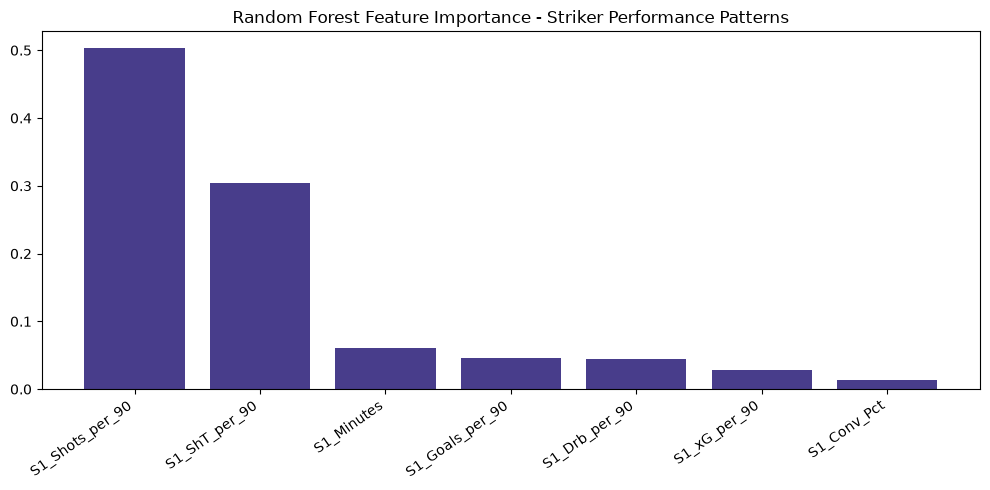

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================================
# 1. FEATURE ENGINEERING BASED ON YOUR EXACT SCHEMA
# ==============================================================================
print("🛠️ Engineering normalized performance features from raw columns...")

def prepare_ml_features(df, season_label):
    df_copy = df.copy()
    
    # Standardize raw volumes into rate-metrics per 90 minutes
    df_copy['Shots_per_90'] = (df_copy['Shots'] / df_copy['Minutes']) * 90
    df_copy['ShT_per_90'] = (df_copy['ShT'] / df_copy['Minutes']) * 90
    
    # Isolate specific performance vectors for pattern recognition
    keep_cols = {
        'Player': 'Player',
        'Minutes': f'{season_label}_Minutes',
        'Conv %': f'{season_label}_Conv_Pct',
        'Goals per 90 minutes': f'{season_label}_Goals_per_90',
        'xG/90': f'{season_label}_xG_per_90',
        'Drb/90': f'{season_label}_Drb_per_90',
        'Shots_per_90': f'{season_label}_Shots_per_90',
        'ShT_per_90': f'{season_label}_ShT_per_90'
    }
    
    return df_copy[list(keep_cols.keys())].rename(columns=keep_cols)

# Build Season 1 training feature matrix
s1_ml_features = prepare_ml_features(season1_df, 'S1')
ml_feature_names = [col for col in s1_ml_features.columns if col != 'Player']

# Isolate the target vector from Season 2 (filtered for stable statistical volume)
s2_stable = season2_df[season2_df['Minutes'] >= 900].copy()
s2_target = s2_stable[['Player', 'Goals per 90 minutes']].rename(columns={'Goals per 90 minutes': 'Target_S2_G90'})

# Merge historical features with subsequent real-world target results
ml_df = pd.merge(s1_ml_features, s2_target, on='Player', how='inner').dropna()

X = ml_df[ml_feature_names]
y = ml_df['Target_S2_G90']

print(f"✅ Matrix built. Mapped {X.shape[0]} historical player records across seasons.")

# ==============================================================================
# 2. MODEL TRAINING & VALIDATION
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest Regressor to capture non-linear metric interactions
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Run test set predictions to verify generalizability
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("🤖 MACHINE LEARNING ENGINE REPORT CARD")
print("="*50)
print(f"📉 Model Error (RMSE): {rmse:.3f} Goals/90 variance")
print(f"📈 Variance Explained (R² Score): {r2:.2f}")
print("="*50 + "\n")

# ==============================================================================
# 3. EXTRACTION OF MATHEMATICAL PATTERNS
# ==============================================================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("📋 RANKED GOALSCORER PATTERNS (By Error Reduction Weight):")
print("This breaks down exactly which Season 1 features carry the highest predictive signal.")
print("-" * 75)
for f in range(X.shape[1]):
    print(f"{f + 1}. Feature: {X.columns[indices[f]]:<25} | Weight Impact: {importances[indices[f]]*100:.2f}%")
print("-" * 75)

# Output pattern visualization plot
plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importance - Striker Performance Patterns")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='darkslateblue')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [15]:
print("📋 Your actual dataset columns are:\n", season1_df.columns.tolist())

📋 Your actual dataset columns are:
 ['Unique ID', 'Player', 'Club', 'Best Pos', 'Age', 'Transfer Value', 'Preferred Foot', 'Appearances', 'Minutes', 'Goals', 'xG', 'Shots', 'ShT', 'Conv %', 'Goals per 90 minutes', 'xG/90', 'Drb/90']
